# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


## Objetivo

O objetivo desta atividade é aplicar o algoritmo de Árvore de Decisão em uma base de credit score, utilizando dados de treino e teste já tratados. O modelo será treinado com o critério de Gini e avaliado por meio de métricas como acurácia, precisão, recall, F1-score e matriz de confusão.

Além disso, será realizada a visualização da árvore, a identificação das principais features do modelo e a comparação do desempenho obtido com o modelo Naive Bayes desenvolvido no módulo anterior.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1 Carregamento das bases de treino e teste

In [2]:
X_train = pd.read_csv("X_train_balanced.csv", delimiter=';')
X_test = pd.read_csv("X_test.csv", delimiter=';')
y_train = pd.read_csv("y_train_balanced.csv",  delimiter=';')
y_test = pd.read_csv("y_test.csv",  delimiter=';')

In [3]:
# Visualiza os dados de treino da base X treino
X_train.head()

,Age,Income,Number of Children,Education_encoded,Gender_Masculino,Marital Status_Solteiro(a),Home Ownership_Próprio
0,33,52.5,0,0,1,1,0
1,48,70.0,1,4,0,0,1
2,26,45.0,0,1,0,1,0
3,50,155.0,0,3,1,0,1
4,36,140.0,0,2,1,0,1


In [4]:
#  Verifica a quantidade linhas e colunas da base X treino
X_train.shape

(270, 7)

In [5]:
# Visualiza os dados de teste da base y treino
y_train.head()

,credit_score_encoded
0,1
1,2
2,1
3,2
4,2


In [6]:
#  Verifica a quantidade linhas e colunas da base y treino
y_train.shape

(270, 1)

In [7]:
# Visualiza os dados de teste da base X teste
X_test.head()

,Age,Income,Number of Children,Education_encoded,Gender_Masculino,Marital Status_Solteiro(a),Home Ownership_Próprio
0,37,75.0,2,2,0,0,1
1,30,105.0,2,3,1,0,1
2,45,110.0,3,2,0,0,1
3,36,95.0,2,3,0,0,1
4,34,47.5,0,1,1,1,0


In [8]:
#  Verifica a quantidade linhas e colunas da base X teste
X_test.shape

(33, 7)

In [9]:
# Visualiza os dados de teste da base y teste
y_test.head()

,credit_score_encoded
0,2
1,2
2,2
3,2
4,1


In [10]:
#  Verifica a quantidade linhas e colunas da base y teste
y_test.shape

(33, 1)

In [11]:
map_score = {
    0: 'Baixo',
    1: 'Médio',
    2: 'Alto'
}

# Contar o número de exemplos de cada classe em y_train
train_balance = y_train['credit_score_encoded'].map(map_score).value_counts().sort_index()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test['credit_score_encoded'].map(map_score).value_counts().sort_index()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
credit_score_encoded
Alto     90
Baixo    90
Médio    90
Name: count, dtype: int64

Balanceamento em y_test:
credit_score_encoded
Alto     23
Baixo     3
Médio     7
Name: count, dtype: int64


In [12]:
y_train = y_train['credit_score_encoded']
y_test = y_test['credit_score_encoded']

# 2 Passo a passo para aplicação do algoritmo de árvore de decisão

Para aplicar o algoritmo de árvore de decisão, é necessário seguir algumas etapas:

1. Importar as bibliotecas: antes de iniciar a análise e a implementação do modelo, é necessário importar as bibliotecas utilizadas para manipulação dos dados, visualização, treinamento e avaliação do modelo.
2. Carregar os dados: nesta etapa, as bases de treino e teste são carregadas, separando as variáveis explicativas, representadas por X, da variável alvo, representada por y.
3. Pré-processamento dos dados: aqui são feitas verificações iniciais, limpeza e tratamento dos dados. Essa etapa pode incluir identificação de inconsistências, tratamento de valores ausentes, transformação de variáveis categóricas, normalização e balanceamento das classes.
4. Separar os dados em treino e teste: os dados de treino são utilizados para o modelo aprender os padrões existentes na base, enquanto os dados de teste são usados para avaliar o desempenho do modelo em dados novos.
5. Treinar o modelo: nesta etapa, o algoritmo de árvore de decisão é aplicado aos dados de treino. O modelo aprende regras de decisão com base nas variáveis explicativas para classificar corretamente a variável alvo.
6. Fazer previsões com os dados de teste: após o treinamento, o modelo é aplicado à base de teste para gerar previsões e verificar como ele se comporta diante de dados que não foram usados no treinamento.
7. Avaliar o modelo: a avaliação é feita por meio de métricas como acurácia, precisão, recall e F1-score. A acurácia mede o percentual geral de acertos do modelo. A precisão avalia, entre as previsões positivas, quantas realmente estavam corretas. O recall mede, entre os casos positivos reais, quantos o modelo conseguiu identificar. Já o F1-score busca equilibrar precisão e recall em uma única métrica.
8. Identificar as principais features: após treinar e avaliar o modelo, é possível analisar quais variáveis tiveram maior importância nas decisões da árvore. A partir disso, podemos testar um novo modelo utilizando apenas as features mais relevantes e comparar seu desempenho com o modelo completo.

# 3 Aplicação da árvore de decisão aos dados de treinamento

In [13]:
decision_tree_model = DecisionTreeClassifier(criterion="gini", random_state=0)

decision_tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [14]:
predictions_train = decision_tree_model.predict(X_train)
predictions_train

array([1, 2, 1, 2, 2, 0, 1, 1, 2, 1, 1, 2, 0, 0, 2, 2, 2, 2, 2, 2, 1, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2,
       1, 2, 1, 0, 2, 2, 2, 2, 1, 2, 1, 1, 2, 1, 2, 0, 2, 2, 2, 1, 1, 0,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       1, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2,
       0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [15]:
y_train

0      1
1      2
2      1
3      2
4      2
      ..
265    1
266    1
267    1
268    1
269    1
Name: credit_score_encoded, Length: 270, dtype: int64

In [16]:
accuracy_train = accuracy_score(y_train, predictions_train)
print(f"Acurácia no treino: {accuracy_train:.4f}")

Acurácia no treino: 1.0000


In [17]:
report_train = classification_report(
    y_train,
    predictions_train,
    target_names=['Baixo', 'Médio', 'Alto']
)

print(report_train)

              precision    recall  f1-score   support

       Baixo       1.00      1.00      1.00        90
       Médio       1.00      1.00      1.00        90
        Alto       1.00      1.00      1.00        90

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



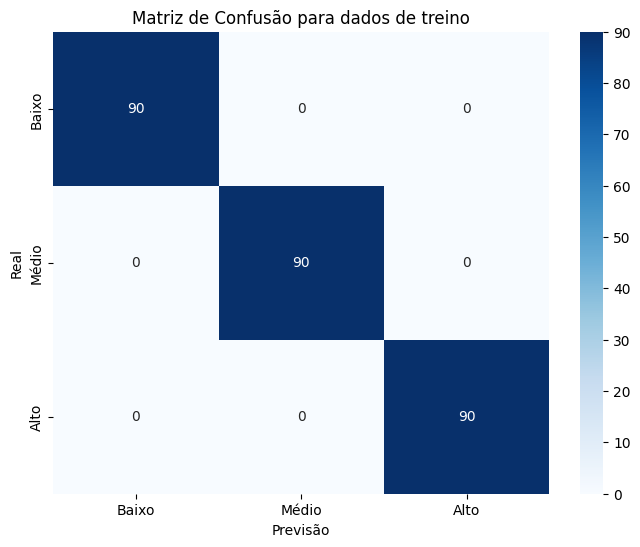

In [18]:
confusion_matrix_train = confusion_matrix(y_train, predictions_train)

# Plotando a matriz de confusão com o mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_train, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para dados de treino')
plt.show()

O modelo de árvore de decisão foi treinado com os dados de treino utilizando o critério de Gini e random_state igual a 0. A base de treino está balanceada, com 90 exemplos para cada classe: Baixo, Médio e Alto.

Na avaliação com os dados de treino, o modelo obteve acurácia de 1,0000, ou seja, classificou corretamente todos os registros da base de treinamento. A matriz de confusão confirma esse resultado, pois todos os valores estão na diagonal principal: 90 acertos para a classe Baixo, 90 acertos para a classe Médio e 90 acertos para a classe Alto, sem erros de classificação.

Esse resultado mostra que o modelo se ajustou muito bem aos dados de treino. No entanto, como a acurácia foi perfeita, é importante comparar com o desempenho na base de teste, pois uma árvore de decisão sem limitação de profundidade pode se ajustar demais aos dados de treinamento e apresentar risco de overfitting.

# 4 Avaliação do modelo com os dados de teste

In [19]:
predictions_test = decision_tree_model.predict(X_test)
predictions_test

array([2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 0, 2, 1,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2])

In [20]:
y_test

0     2
1     2
2     2
3     2
4     1
5     2
6     2
7     2
8     1
9     2
10    2
11    1
12    2
13    1
14    2
15    1
16    2
17    2
18    2
19    0
20    1
21    1
22    2
23    2
24    2
25    0
26    2
27    2
28    2
29    2
30    2
31    0
32    2
Name: credit_score_encoded, dtype: int64

In [21]:
accuracy_test = accuracy_score(y_test, predictions_test)
print(f"Acurácia: {accuracy_test:.4f}")

Acurácia: 0.9394


In [34]:
report_test = classification_report(y_test, predictions_test, target_names=['Baixo', 'Médio', 'Alto'])
print(report_test)

              precision    recall  f1-score   support

       Baixo       1.00      1.00      1.00         3
       Médio       0.86      0.86      0.86         7
        Alto       0.96      0.96      0.96        23

    accuracy                           0.94        33
   macro avg       0.94      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33



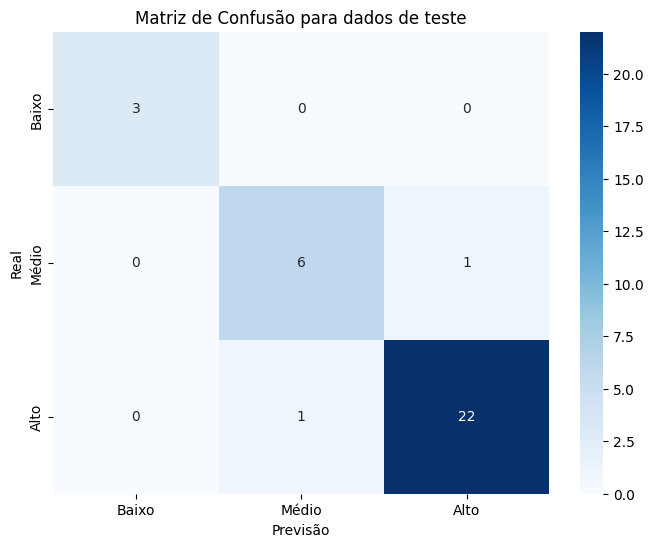

In [23]:
confusion_matrix_test = confusion_matrix(y_test, predictions_test)

# Plotando a matriz de confusão com o mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_test, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para dados de teste')
plt.show()

Na base de treino, o modelo obteve acurácia de 1,0000, ou seja, classificou corretamente todos os exemplos utilizados no treinamento. Já na base de teste, a acurácia foi de 0,9394, indicando que o modelo acertou aproximadamente 93,94% dos casos novos.

A matriz de confusão mostra que a classe Baixo foi classificada corretamente em todos os casos. Para a classe Médio, o modelo acertou 6 registros e classificou 1 como Alto. Para a classe Alto, o modelo acertou 22 registros e classificou 1 como Médio.

Apesar do bom desempenho na base de teste, a acurácia perfeita no treino pode indicar que a árvore se ajustou muito bem aos dados de treinamento. Como o desempenho no teste também foi alto, o modelo apresentou boa capacidade de generalização, mas ainda assim é importante observar a profundidade da árvore para verificar possível overfitting.

# 5 Visualização da árvore de decisão

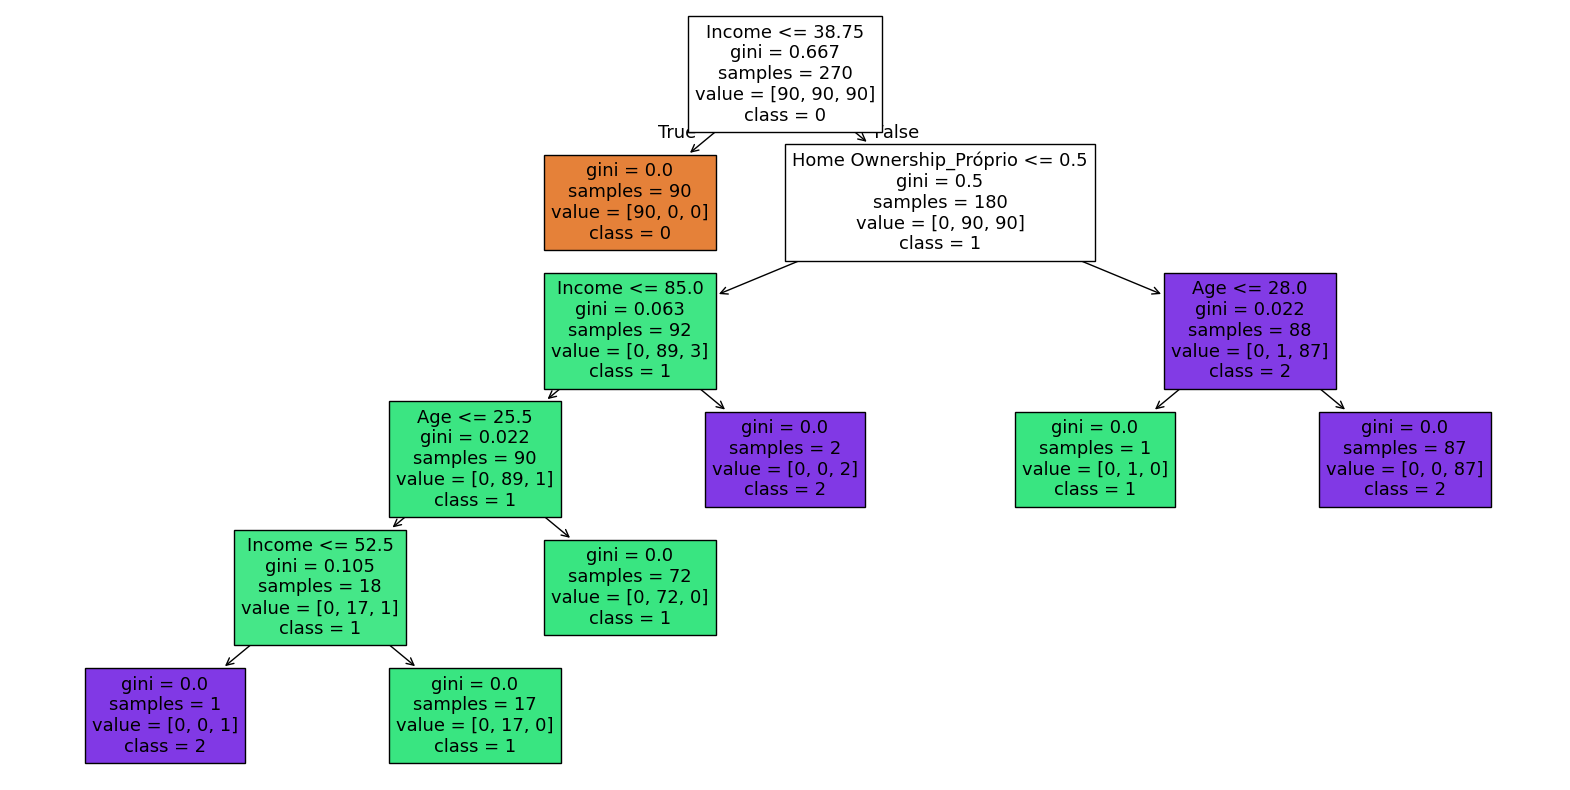

In [24]:
plt.figure(figsize=(20,10))
plot_tree(decision_tree_model, filled=True, feature_names=X_train.columns, class_names=['Baixo', 'Médio', 'Alto'])
plt.show()

In [25]:
print("Profundidade da árvore:", decision_tree_model.get_depth())
print("Quantidade de folhas:", decision_tree_model.get_n_leaves())

Profundidade da árvore: 5
Quantidade de folhas: 7


A árvore de decisão foi plotada para permitir uma avaliação visual das regras criadas pelo modelo. A primeira divisão foi feita pela variável Income, indicando que essa feature teve grande importância na separação inicial das classes.

A visualização mostra que a árvore consegue separar bem as classes Baixo, Médio e Alto, criando nós com Gini próximo de zero em várias divisões. Isso indica nós mais puros, ou seja, grupos em que a maioria dos registros pertence à mesma classe.

No entanto, quando a árvore cresce muito, a interpretação visual pode se tornar mais difícil. Por isso, além da visualização, é importante analisar a profundidade da árvore e comparar o desempenho entre treino e teste, pois árvores muito profundas podem apresentar overfitting.

# 6 Identificação das principais features do modelo


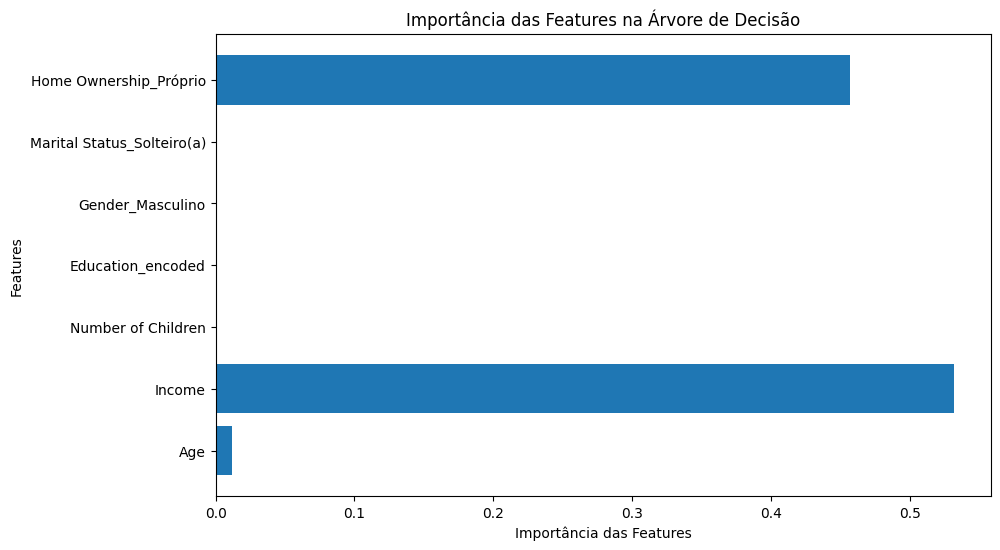

In [26]:
# Obtendo a importância das características do modelo de árvore de decisão
importance_variables = decision_tree_model.feature_importances_

# Obtendo os nomes das características
feature_names = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_variables)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

As duas principais features do modelo foram Income e Home Ownership_Próprio. A variável Income apresentou a maior importância, indicando que a renda teve forte influência na separação das classes de credit score. A variável Home Ownership_Próprio também teve grande relevância, mostrando que possuir ou não imóvel próprio contribuiu para a classificação realizada pela árvore.

As demais variáveis apresentaram importância muito baixa ou nula no modelo, indicando que tiveram pouca influência nas divisões feitas pela árvore de decisão.

# 7 Aplicação da árvore de decisão com as duas principais features

In [27]:
X_train_reduced = X_train[['Home Ownership_Próprio', 'Income']]
X_test_reduced = X_test[['Home Ownership_Próprio', 'Income']]

In [28]:
decision_tree_reduced = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
decision_tree_reduced.fit(X_train_reduced, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [29]:
predictions_reduced = decision_tree_reduced.predict(X_test_reduced)
predictions_reduced

array([2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 0, 2, 1,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2])

In [30]:
y_test

0     2
1     2
2     2
3     2
4     1
5     2
6     2
7     2
8     1
9     2
10    2
11    1
12    2
13    1
14    2
15    1
16    2
17    2
18    2
19    0
20    1
21    1
22    2
23    2
24    2
25    0
26    2
27    2
28    2
29    2
30    2
31    0
32    2
Name: credit_score_encoded, dtype: int64

In [36]:
accuracy_reduced = accuracy_score(y_test, predictions_reduced)

print(f"Acurácia do modelo com 2 principais features: {accuracy_reduced:.4f}")

Acurácia do modelo com 2 principais features: 0.9394


In [31]:
report_reduced = classification_report(y_test, predictions_reduced, target_names=['Baixo', 'Médio', 'Alto'])
print("Relatório de Classificação:")
print(report_reduced)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.86      0.86      0.86         7
           2       0.96      0.96      0.96        23

    accuracy                           0.94        33
   macro avg       0.94      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33



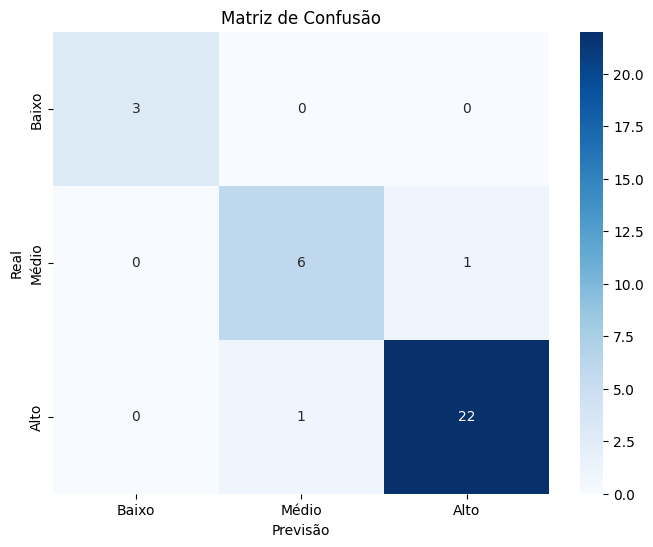

In [32]:
confusion_matrix_reduced = confusion_matrix(y_test, predictions_reduced)

# Plotando a matriz de confusão com o mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_reduced, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

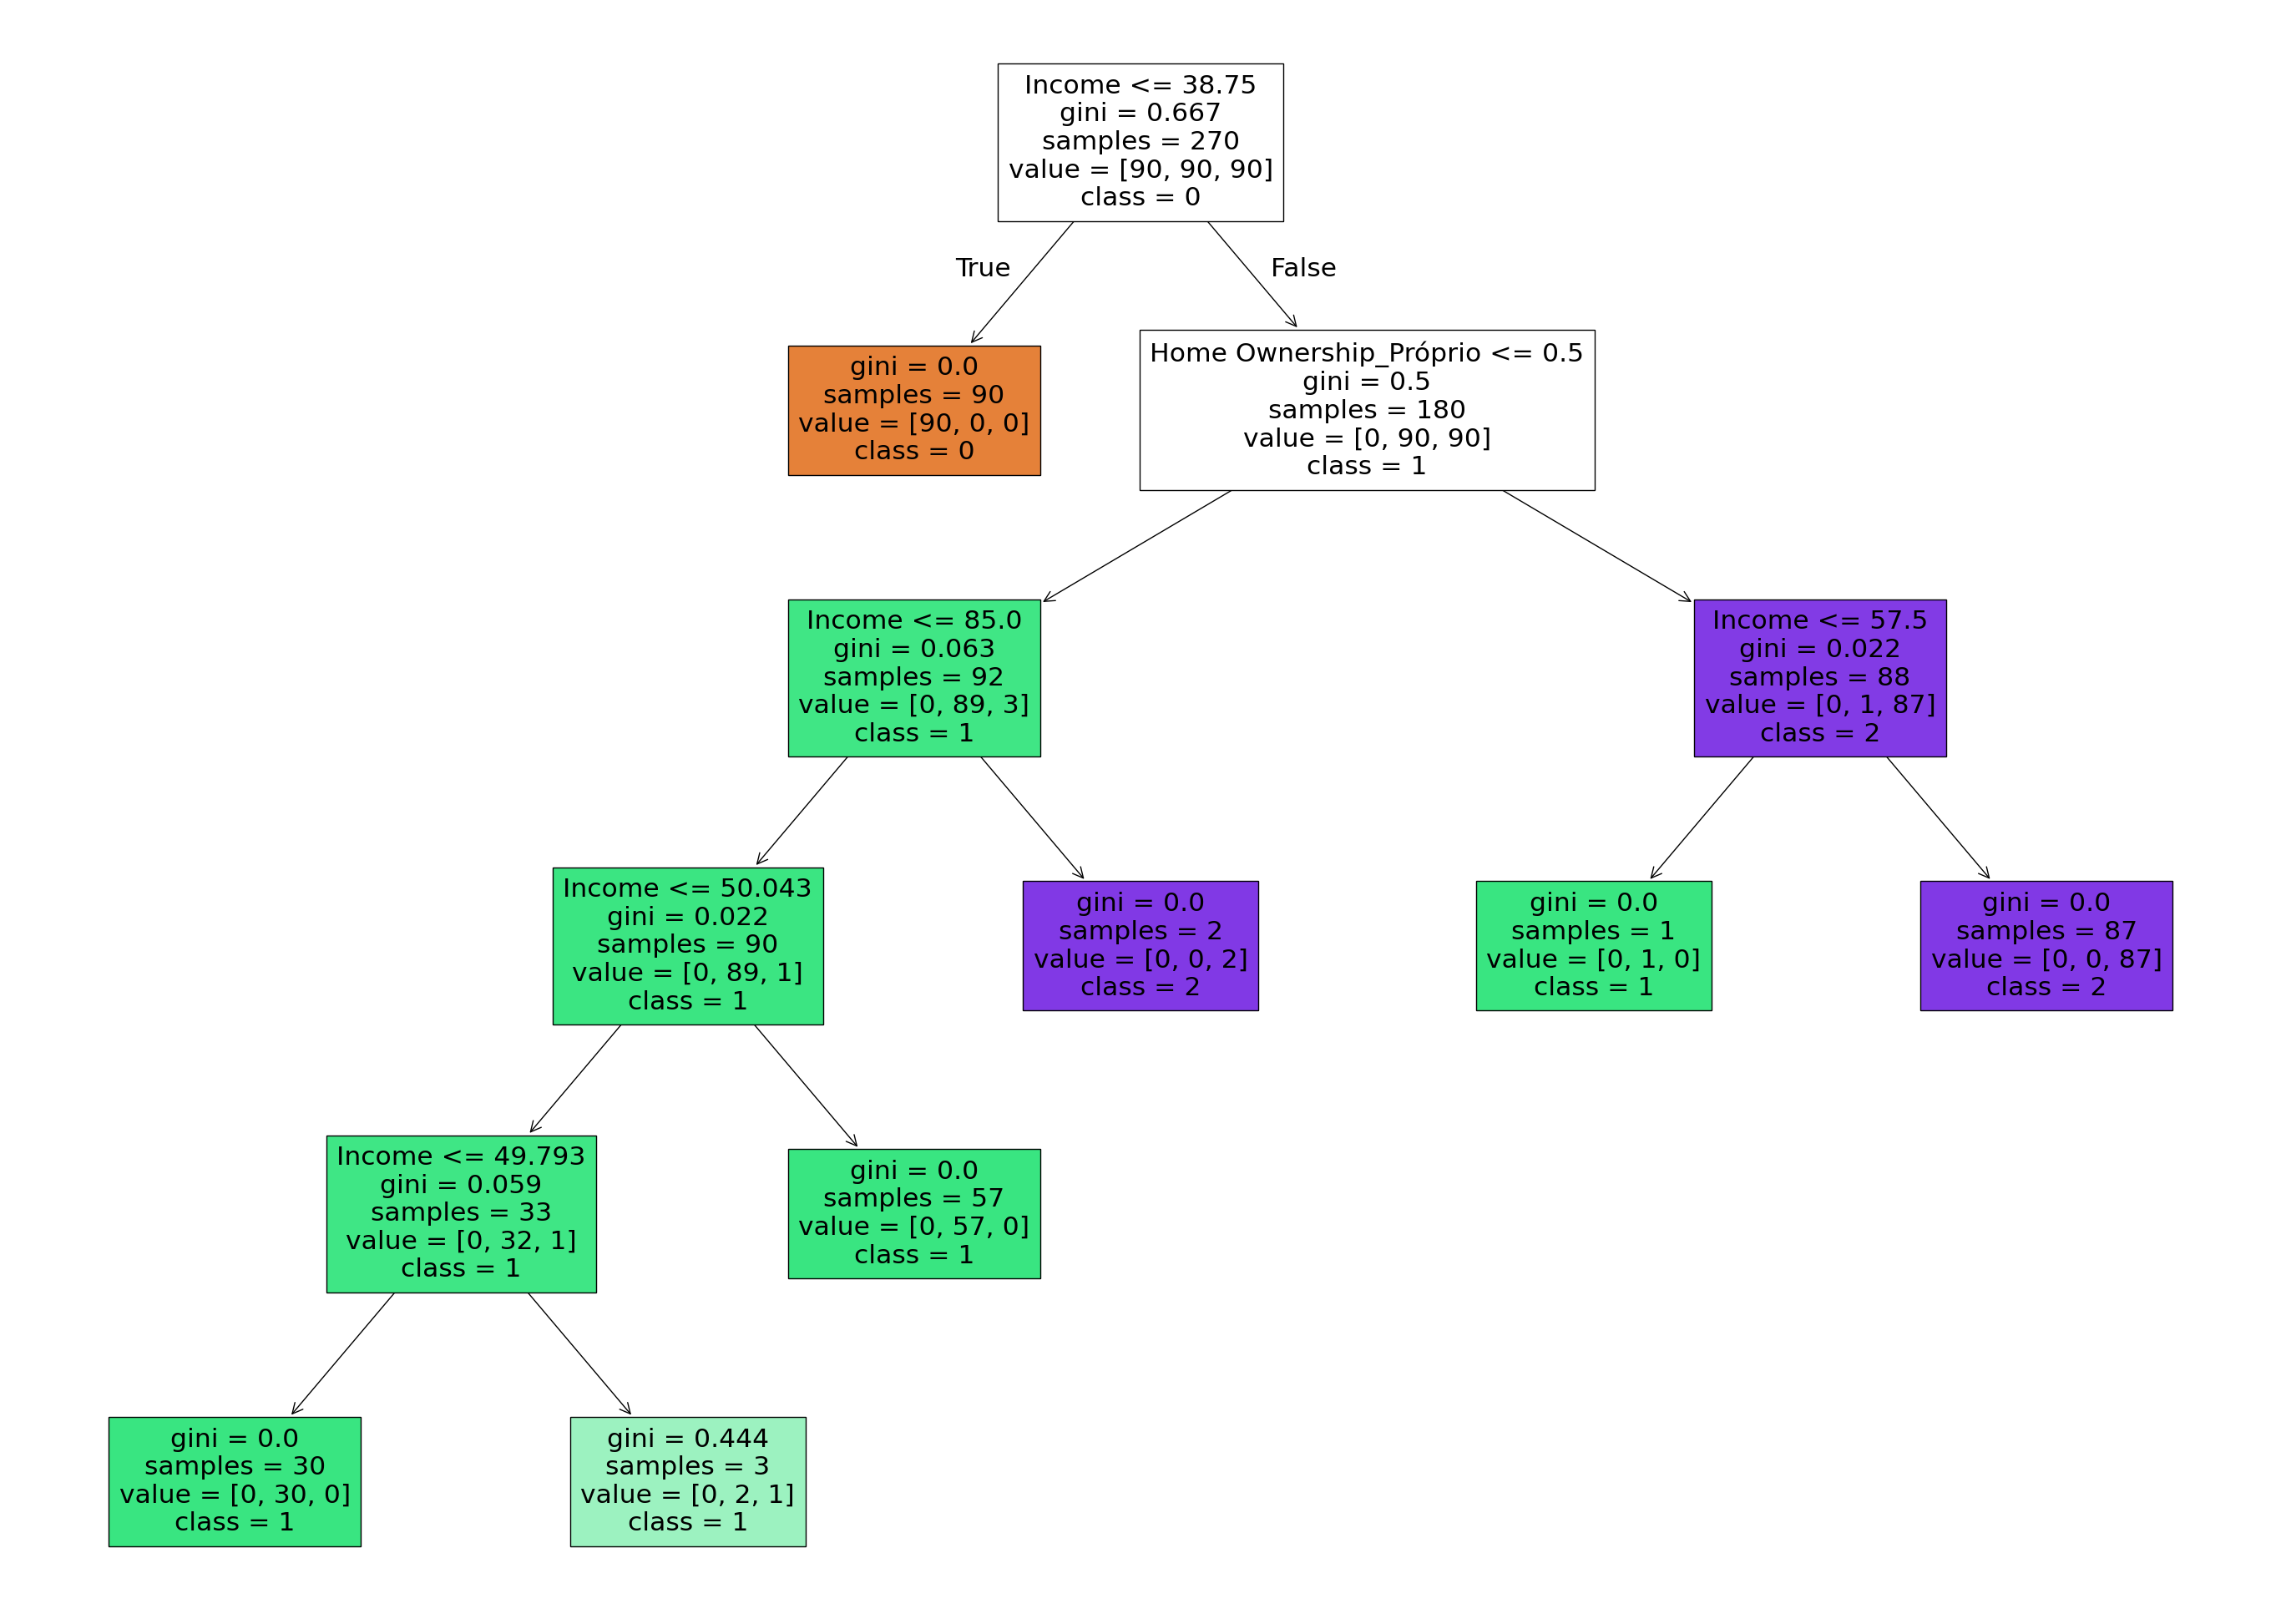

In [33]:
plt.figure(figsize=(35,25))
plot_tree(decision_tree_reduced, filled=True, feature_names=X_train_reduced.columns, class_names=['Baixo', 'Médio', 'Alto'])
plt.show()

# 8 Comparação entre árvore de decisão e Naive Bayes

In [38]:
comparison_of_models = pd.DataFrame({
    'Modelo': [
        'Naive Bayes',
        'Árvore de Decisão - Completa',
        'Árvore de Decisão - 2 principais features'
    ],
    'Acurácia no teste': [
        0.9394,
        accuracy_test,
        accuracy_reduced
    ]
})

comparison_of_models

,Modelo,Acurácia no teste
0,Naive Bayes,0.939400
1,Árvore de Decisão - Completa,0.939394
2,Árvore de Decisão - 2 principais features,0.939394


Comparando os resultados da árvore de decisão com os resultados do Naive Bayes do módulo 20, observa-se que os dois modelos apresentaram desempenho muito semelhante na base de teste. O modelo Naive Bayes obteve acurácia de 0,9394 e recall macro de 0,9379, enquanto a árvore de decisão também apresentou acurácia de 0,9394 na base de teste.

Na base de treino, a árvore de decisão obteve acurácia de 1,0000, enquanto o Naive Bayes apresentou acurácia de 0,9556. Isso mostra que a árvore se ajustou melhor aos dados de treinamento, mas também indica maior risco de overfitting, já que árvores de decisão podem criar regras muito específicas quando não há limitação de profundidade.

Apesar disso, a árvore manteve bom desempenho na base de teste e apresentou bons valores de precisão, recall e F1-score para as três classes. Além disso, ela tem a vantagem de permitir uma interpretação visual das regras utilizadas pelo modelo, mostrando que as variáveis Income e Home Ownership_Próprio tiveram grande importância na classificação.

Portanto, os dois modelos se adequaram bem aos dados e apresentaram bons resultados de avaliação. Como a acurácia no teste foi igual, não é possível afirmar que um modelo foi muito superior ao outro. No entanto, a árvore de decisão se mostrou mais interpretável para esta atividade, enquanto o Naive Bayes também apresentou bom desempenho com uma estrutura mais simples.